In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df_2 = pd.read_parquet("../../output/prises_de_parole.parquet")

In [27]:
data = df_2[["dateSeance","texte","nb_caracteres","nb_mots","nom_orateur"]]

# On commence à faire des statistiques sur les différents orateurs

In [32]:
print(data["nom_orateur"].nunique())

2162


In [29]:
interventions_par_orateur = data["nom_orateur"].value_counts()
print(interventions_par_orateur)

nom_orateur
Mme la présidente         81699
                          25572
M. le président           10729
M. Éric Dupond-Moretti     3333
M. Gabriel Attal           3002
                          ...  
Mme Dominique Vérien          1
M. Claude Malhuret            1
Mme Cécile Cukierman          1
Mme Mélanie Vogel             1
Mme Maryse Carrère            1
Name: count, Length: 2162, dtype: int64


In [31]:
# Filtrer les orateurs avec exactement 1 intervention
orateurs_une_fois = interventions_par_orateur[interventions_par_orateur == 1]

# Nombre de personnes ayant parlé une seule fois
nombre_orateurs_une_fois = len(orateurs_une_fois)

print(f"Nombre de personnes ayant parlé une seule fois : {nombre_orateurs_une_fois}")
print("Liste des orateurs :")
print(orateurs_une_fois)

Nombre de personnes ayant parlé une seule fois : 733
Liste des orateurs :
nom_orateur
Un député du groupe LaREM          1
M. Christophe Euzet                1
M. Éric Diard                      1
M. Philippe Benassaya              1
Un député du groupe LFI – NUPES    1
                                  ..
Mme Dominique Vérien               1
M. Claude Malhuret                 1
Mme Cécile Cukierman               1
Mme Mélanie Vogel                  1
Mme Maryse Carrère                 1
Name: count, Length: 733, dtype: int64


In [33]:
total_orateurs = len(interventions_par_orateur)
pourcentage = (nombre_orateurs_une_fois / total_orateurs) * 100
print(f"Pourcentage d'orateurs uniques : {pourcentage:.2f}%")

Pourcentage d'orateurs uniques : 33.90%


# On regarde maintenant les dates et le nombre de mots utiliser 

In [ ]:
data["dateSeance"] = pd.to_datetime(data["dateSeance"])
data["annee_mois"] = data["dateSeance"].dt.to_period("M")

In [38]:
interventions_par_mois = data.groupby("annee_mois").size()
print(interventions_par_mois)

annee_mois
2021-02      224
2022-06       59
2022-07    16944
2022-08     1958
2022-10    24519
2022-11    19071
2022-12    17462
2023-01    10058
2023-02    17951
2023-03    22348
2023-04     8412
2023-05    22943
2023-06    21255
2023-07    22029
2023-09     7961
2023-10    17321
2023-11    19961
2023-12     9368
2024-01    10237
2024-02     9992
2024-03    16217
2024-04     8899
2024-05    24754
2024-06     7098
Freq: M, dtype: int64


In [39]:
moyenne_caracteres_par_mois = data.groupby("annee_mois")["nb_caracteres"].mean()
moyenne_mots_par_mois = data.groupby("annee_mois")["nb_mots"].mean()

print("Moyenne de caractères par mois :\n", moyenne_caracteres_par_mois)
print("Moyenne de mots par mois :\n", moyenne_mots_par_mois)

Moyenne de caractères par mois :
 annee_mois
2021-02    797.129464
2022-06    498.338983
2022-07    322.546919
2022-08    430.357508
2022-10    342.094253
2022-11    317.946725
2022-12    279.995476
2023-01    431.291012
2023-02    320.045513
2023-03    323.781367
2023-04    368.628507
2023-05    313.288933
2023-06    331.267090
2023-07    249.869763
2023-09    274.993594
2023-10    327.046360
2023-11    343.898753
2023-12    337.122331
2024-01    375.544495
2024-02    366.086970
2024-03    353.774743
2024-04    406.489044
2024-05    315.502585
2024-06    304.863905
Freq: M, Name: nb_caracteres, dtype: float64
Moyenne de mots par mois :
 annee_mois
2021-02    130.080357
2022-06     79.220339
2022-07     52.173336
2022-08     69.654750
2022-10     55.183939
2022-11     51.424204
2022-12     44.840339
2023-01     68.584808
2023-02     52.023731
2023-03     52.011097
2023-04     58.882668
2023-05     50.356318
2023-06     53.011244
2023-07     40.032139
2023-09     44.422183
2023-10     5

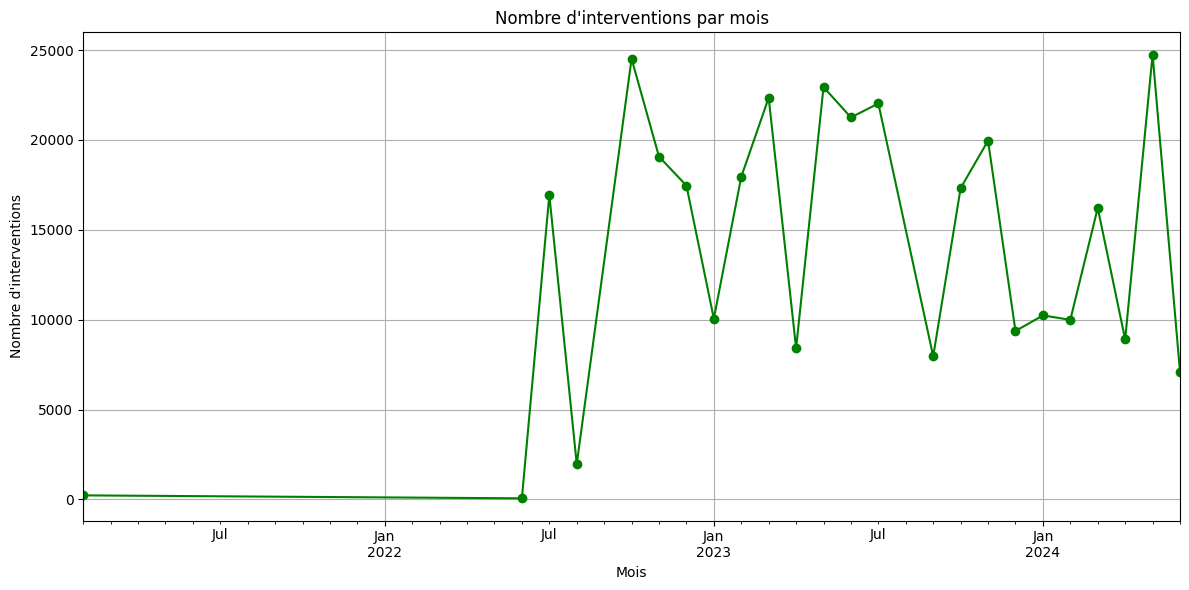

In [41]:
plt.figure(figsize=(12, 6))
interventions_par_mois.plot(marker="o", linestyle="-", color="green")
plt.title("Nombre d'interventions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'interventions")
plt.grid(True)
plt.tight_layout()
plt.show()

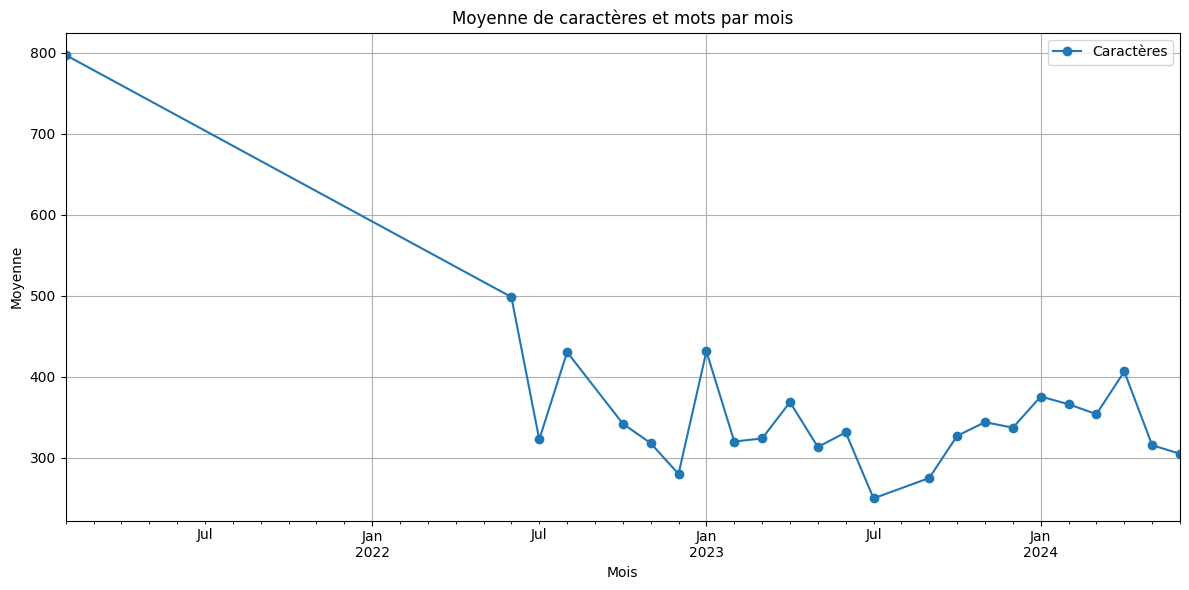

In [44]:
plt.figure(figsize=(12, 6))
moyenne_caracteres_par_mois.plot(label="Caractères", marker="o")
plt.title("Moyenne de caractères et mots par mois")
plt.xlabel("Mois")
plt.ylabel("Moyenne")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

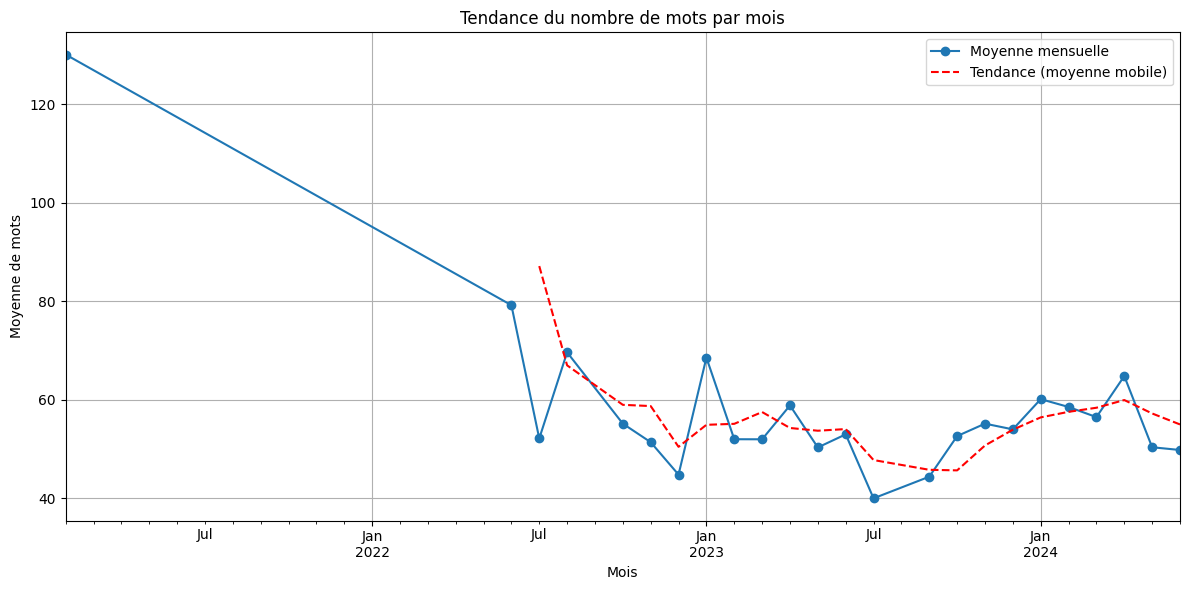

In [43]:
# Calcul de la tendance (moyenne mobile sur 3 mois)
moyenne_mobile = moyenne_mots_par_mois.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
moyenne_mots_par_mois.plot(label="Moyenne mensuelle", marker="o")
moyenne_mobile.plot(label="Tendance (moyenne mobile)", linestyle="--", color="red")
plt.title("Tendance du nombre de mots par mois")
plt.xlabel("Mois")
plt.ylabel("Moyenne de mots")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

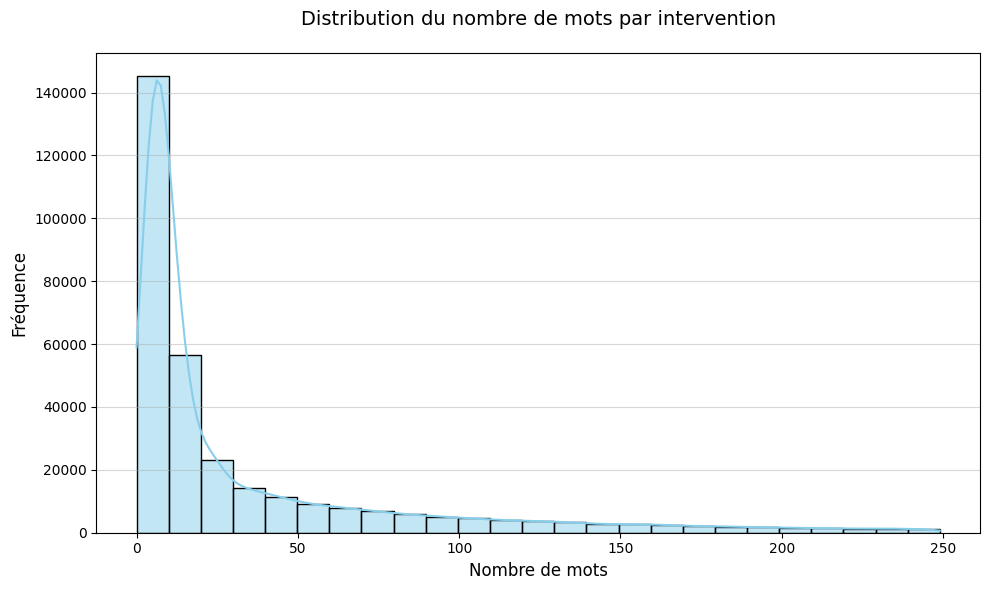

In [51]:
# Configuration de la taille de la figure
plt.figure(figsize=(10, 6))

# Création de l'histogramme avec Seaborn (plus esthétique)
sns.histplot(data=data[data.nb_mots<250], x="nb_mots", bins=25, kde=True, color="skyblue", edgecolor="black")

# Ajout des titres et labels
plt.title("Distribution du nombre de mots par intervention", fontsize=14, pad=20)
plt.xlabel("Nombre de mots", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.grid(axis="y", alpha=0.5)

# Affichage
plt.tight_layout()
plt.show()